In [1]:
# Parameters
summary_config = {"run_run_comparison": False, "run_RTP_summary": False, "run_validation": True, "run_network_validation": True, "summary_list": {"RTP-summary-notebook": ["RTP_index", "RTP_congestion", "RTP_topsheet", "RTP_MIC", "RTP_person", "RTP_household", "RTP_access", "RTP_costs", "RTP_walk_bike", "RTP_emissions", "RTP_mode_share", "RTP_freight", "RTP_transit"], "activitysim-validation-notebook": ["work_from_home", "auto_ownership", "telecommute_frequency", "free_parking", "cdap", "intermediate_stop_frequency", "trip_purpose", "trip_destination_choice", "school_location", "work_location", "mandatory_tour_frequency", "mandatory_tour_scheduling", "non_mandatory_tour_frequency", "non_mandatory_tour_destination_choice", "non_mandatory_tour_scheduling", "joint_tour_frequency", "joint_tour_composition", "atwork_subtours_frequency", "atwork_subtours_destination_choice", "atwork_subtours_scheduling", "atwork_subtour_mode", "tour_mode_choice", "trip_mode_choice"], "daysim-validation-notebook": ["all_tour_mode", "all_trip_mode", "auto_ownership", "day_pattern", "escort_tour_mode", "escort_trip_mode", "households", "intermediate_stop_generation", "other_home_based_tour_mode", "other_home_based_trip_mode", "persons", "school_location", "school_tour_mode", "school_trip_mode", "telecommute", "time_choice", "tours", "tour_destination", "transit_pass_ownership", "trips", "trip_destination", "workbased_subtour_generation", "workbased_subtour_mode", "work_location", "work_tour_mode", "work_trip_mode"], "network-validation-notebook": ["JBLM", "supplementals", "transit_validation", "traffic_validation", "bike_validation", "link_analysis"], "run-comparison-notebook": ["topsheet", "population", "parking", "vmt", "transit"]}, "p_output_dir": "outputs/summary", "output_folder": "outputs", "survey_folder": "inputs/base_year/survey", "uncloned_folder": "uncloned", "sc_run_name": "current run", "sc_run_path": "../../../../", "survey_directories": {"survey": "../../../../inputs/base_year/survey"}, "comparison_runs_list": {"2050 new transit, old network": "\\\\modelstation3\\c$\\Workspace\\sc_new_2050_transit\\soundcast", "2050 urbansim": "\\\\modelstation2\\c$\\Workspace\\sc_2050_urbansim2_07_30_25"}, "county_map": {"33": "King", "35": "Kitsap", "53": "Pierce", "61": "Snohomish"}, "uc_list": ["@sov_inc1", "@sov_inc2", "@sov_inc3", "@hov2_inc1", "@hov2_inc2", "@hov2_inc3", "@hov3_inc1", "@hov3_inc2", "@hov3_inc3", "@av_sov_inc1", "@av_sov_inc2", "@av_sov_inc3", "@av_hov2_inc1", "@av_hov2_inc2", "@av_hov2_inc3", "@av_hov3_inc1", "@av_hov3_inc2", "@av_hov3_inc3", "@tnc_inc1", "@tnc_inc2", "@tnc_inc3", "@mveh", "@hveh", "@bveh"], "agency_lookup": {"1": "King County Metro", "2": "Pierce Transit", "3": "Community Transit", "4": "Kitsap Transit", "5": "Washington Ferries", "6": "Sound Transit", "7": "Everett Transit"}, "emissions_scenario": "standard", "tot_veh_model_base_year": 3185281, "speed_bins": [-999999.0, 2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67.5, 72.5, 999999.0], "fac_type_lookup": {"0": 0, "1": 4, "2": 4, "3": 5, "4": 5, "5": 5, "6": 3, "7": 5, "8": 0}, "tod_lookup": {"5to6": 5, "6to7": 6, "7to8": 7, "8to9": 8, "9to10": 9, "10to14": 10, "14to15": 14, "15to16": 15, "16to17": 16, "17to18": 17, "18to20": 18, "20to5": 20}, "summer_list": [87], "special_route_lookup": {"1671": "A-Line Rapid Ride", "1672": "B-Line Rapid Ride", "1673": "C-Line Rapid Ride", "1674": "D-Line Rapid Ride", "1675": "E-Line Rapid Ride", "1677": "H-Line Rapid Ride", "4950": "Central Link", "6995": "Tacoma Link", "6998": "Sounder South", "6999": "Sounder North", "3701": "Swift Blue Line", "3702": "Swift Green Line"}}
input_config = {"debug_skims_and_paths": False, "model_year": "2023", "base_year": "2023", "landuse_inputs": "23_on_23_v3", "network_inputs": "base_year_2023_final", "db_name": "soundcast_inputs_2023.db", "soundcast_inputs_dir": "R:/e2projects_two/SoundCast/Inputs/rtp_2026_2050", "abm_model": "daysim", "run_accessibility_calcs": False, "run_setup_emme_project_folders": False, "run_setup_emme_bank_folders": False, "run_copy_scenario_inputs": False, "run_import_networks": False, "run_skims_and_paths_free_flow": False, "run_skims_and_paths": False, "run_truck_model": False, "run_supplemental_trips": False, "run_daysim": False, "run_summaries": True, "include_av": False, "include_tnc": True, "tnc_av": False, "include_tnc_to_transit": False, "include_knr_to_transit": False, "include_delivery": False, "include_telecommute": True, "run_integrated": False, "should_build_shadow_price": False, "delete_banks": False, "include_tnc_emissions": True, "add_distance_pricing": False, "distance_rate_dict": {"am": 13.5, "md": 8.5, "pm": 13.5, "ev": 8.5, "ni": 8.5}}


In [2]:
import os
import pandas as pd
import numpy as np
import h5py
from sqlalchemy import create_engine
from scipy import stats
import plotly.express as px
import toml
import sys

sys.path.append("../../notebook_styling")
import psrc_theme

input_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration', 'input_configuration.toml'))
valid_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration', 'validation_configuration.toml'))
emme_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration','emme_configuration.toml'))
network_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration','network_configuration.toml'))

# create connection
conn = create_engine('sqlite:///../../../../inputs/db/'+input_config['db_name'])

# summary data location
csv_path = os.path.join(valid_config['model_dir'], 'outputs/validation')

# table format
pd.options.display.float_format = '{:0,.0f}'.format
format_percent = "{:,.1%}".format

## VMT

In [3]:
df = pd.read_csv(os.path.join(valid_config['model_dir'], r'outputs/network/county_network.csv'))
df.index = df.county_name
df.loc['Total',:] = df.sum().values
df = df[['VMT','VHT','delay']]
df

,VMT,VHT,delay
county_name,,,
King,"43,339,968","1,367,168","149,281"
Kitsap,"4,301,412","126,797","2,553"
Outside Region,"336,683","6,514",0
Pierce,"18,392,784","547,806","30,297"
Snohomish,"16,103,906","466,525","29,615"
Total,"82,474,753","2,514,810","211,746"


In [4]:
df = pd.read_csv(os.path.join(valid_config['model_dir'], r'outputs/network/county_network.csv'))

df_obs = pd.read_sql("SELECT * FROM observed_vmt WHERE year="+str(input_config['base_year']), con=conn)
df_obs.rename(columns={'vmt': 'observed'}, inplace=True)

df = df[['county_name','VMT']].merge(df_obs, left_on='county_name', right_on='county')
df.rename(columns={'VMT': 'model'}, inplace=True)
df.index = df['county']
df[['observed','model']] = df[['observed','model']].astype('float')

df.loc['Total',:] = df.sum().values

df['% diff'] = (df['model']-df['observed'])/df['observed']
df[['% diff']] = df[['% diff']].applymap(format_percent)
df[['model','observed','% diff']]

C:\Users\modeller\AppData\Local\Temp\ipykernel_35540\2489709904.py:14: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,model,observed,% diff
county,,,
King,"43,339,968","43,820,112",-1.1%
Kitsap,"4,301,412","4,840,030",-11.1%
Pierce,"18,392,784","17,994,803",2.2%
Snohomish,"16,103,906","15,825,794",1.8%
Total,"82,138,070","82,480,739",-0.4%


## Daily Traffic Counts

In [5]:
df = pd.read_csv(os.path.join(csv_path, 'daily_volume.csv'))
df[['modeled', 'observed']] = df[['modeled', 'observed']].astype('float')
_df = df.groupby('@facilitytype').sum()[['observed', 'modeled']]
_df.loc['Total', :] = _df.sum().values
_df['diff'] = _df['modeled'] - _df['observed']
_df['percent_diff'] = _df['diff'] / _df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

C:\Users\modeller\AppData\Local\Temp\ipykernel_35540\3988584661.py:7: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,diff,percent_diff
@facilitytype,,,,
Arterial,"25,961,517","24,582,733","-1,378,784",-5.3%
Busway,"4,664","3,588","-1,076",-23.1%
Collector,"2,438,324","1,982,312","-456,012",-18.7%
Freeway,"46,630,443","45,733,159","-897,284",-1.9%
HOV,"246,054","280,893","34,839",14.2%
Ramp,"346,844","264,303","-82,541",-23.8%
Total,"75,627,846","72,846,988","-2,780,858",-3.7%


In [6]:
df = pd.read_csv(os.path.join(csv_path,'daily_volume_county_facility.csv'))
df[['modeled','observed']] = df[['modeled','observed']].astype('float')

_df = df.groupby('county').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

C:\Users\modeller\AppData\Local\Temp\ipykernel_35540\4255960492.py:8: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,diff,percent_diff
county,,,,
King,"41,577,117","41,070,178","-506,939",-1.2%
Kitsap,"3,818,020","2,879,350","-938,670",-24.6%
Pierce,"17,288,029","16,622,404","-665,625",-3.9%
Snohomish,"12,944,680","12,275,056","-669,624",-5.2%
Total,"75,627,846","72,846,988","-2,780,858",-3.7%


## Daily Traffic Scatterplot

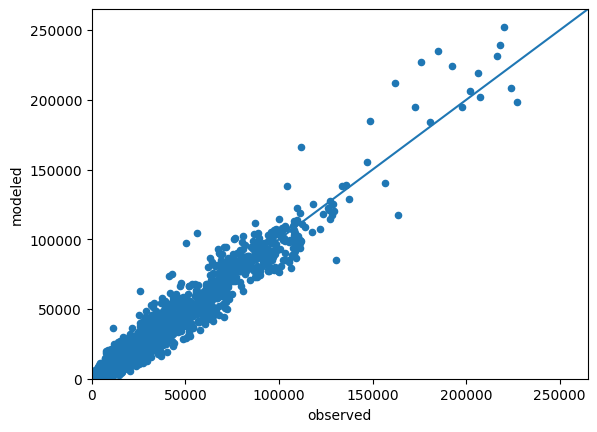

In [7]:
df = pd.read_csv(os.path.join(csv_path,'daily_volume.csv'))
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)

In [8]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2: ' + str(r_value))

r^2: 0.9754168759715426


King r^2: 0.9788349645394183
Kitsap r^2: 0.9520250059440961
Pierce r^2: 0.9782098300567335
Snohomish r^2: 0.9715699819587751


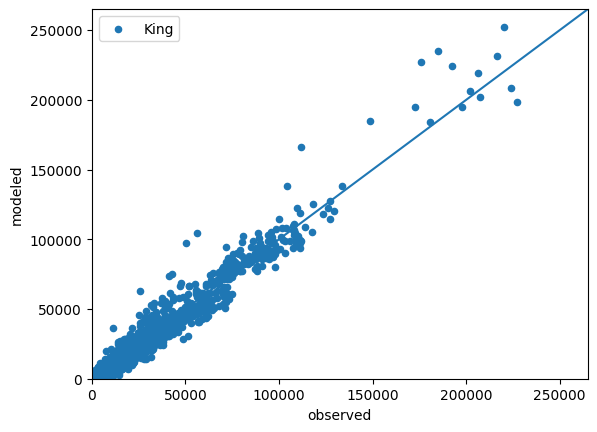

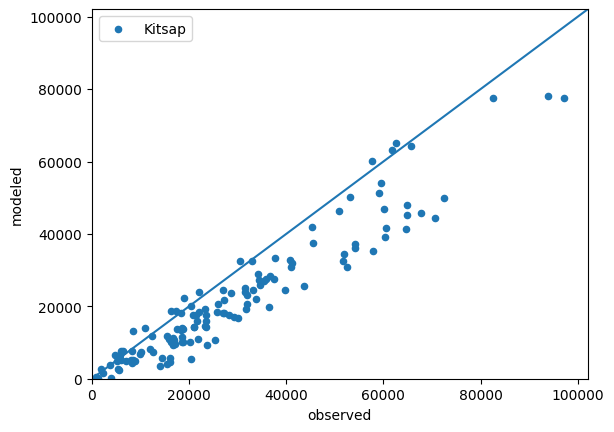

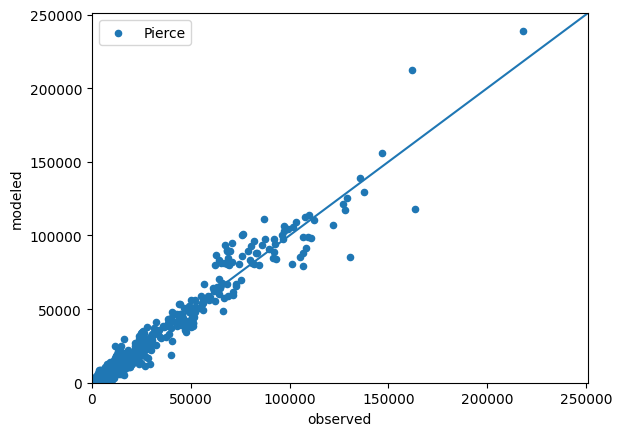

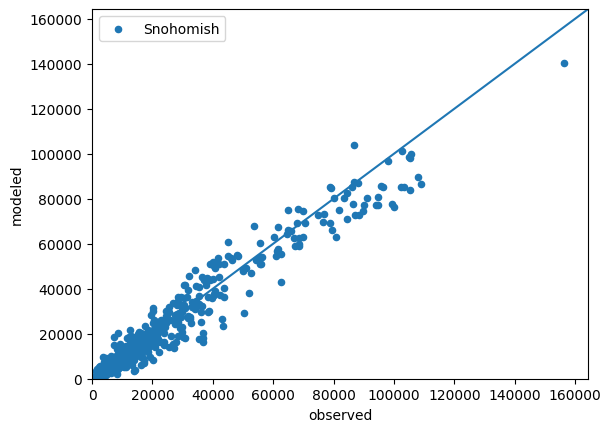

In [9]:
for county in np.unique(df['county']):
    _df = df[df['county'] == county]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=county)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    print(str(county) + ' r^2: ' + str(r_value))

In [10]:
df['@facilitytype'].unique()

array(['Freeway', 'Ramp', 'HOV', 'Arterial', 'Collector', 'Busway'],
      dtype=object)

r^2 Freeway: 0.9577462230807942


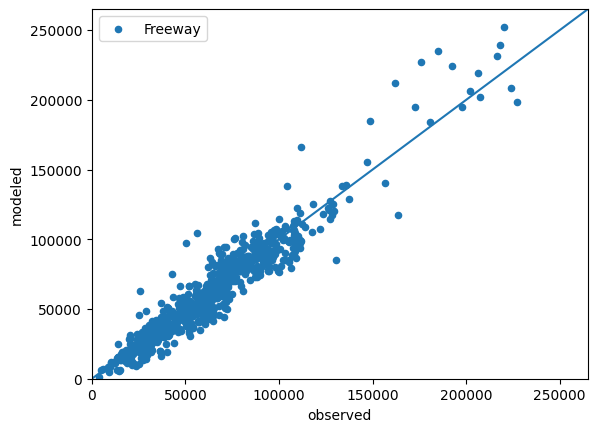

In [11]:
# for factype in ['Freeway','Arterial']:
for factype in ['Freeway']:
    _df = df[df['@facilitytype'] == factype]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    print('r^2 ' + str(factype) + ': ' + str(r_value))

In [12]:
## hourly volumnes

In [13]:
# df = pd.read_csv(os.path.join(csv_path,'hourly_volume.csv'))
# ax = df.plot(kind='scatter', x='observed', y='modeled')
# lim = df[['observed','modeled']].max().max()*1.05
# ax.set_ylim(0,lim)
# ax.set_xlim(0,lim)
# x = np.linspace(*ax.get_xlim())
# ax.plot(x, x)
# slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
# print('r^2: ' + str(r_value))

## Screenlines

In [14]:
df = pd.read_csv(os.path.join(csv_path,'screenlines.csv'))
df.loc[df.index.max() + 1]= df.sum(numeric_only=True)
#df = df.append(df.sum(numeric_only=True), ignore_index=True)
df.at[df.index[-1], 'name'] = 'TOTAL'
#df.at['C', 'name'] = 10
df['percent_diff'] = df['diff']/df['observed']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df

C:\Users\modeller\AppData\Local\Temp\ipykernel_35540\2463447694.py:7: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,name,observed,modeled,county,diff,percent_diff
0,AUBURN - SOUTH KING,"592,476","516,559",King,"-75,917",-12.8%
1,KENT,"559,335","486,976",King,"-72,359",-12.9%
2,SHIP CANAL,"481,563","506,568",King,"25,005",5.2%
3,SEATTLE - SOUTH OF CBD,"473,322","459,763",King,"-13,559",-2.9%
4,MILL CREEK,"391,447","371,056",King,"-20,391",-5.2%
5,SOUTH BELLEVUE,"389,700","357,945",King,"-31,755",-8.1%
6,KIRKLAND-REDMOND,"380,783","387,867",King,"7,084",1.9%
7,SEATTLE - NORTH,"356,051","343,674",King,"-12,377",-3.5%
8,TACOMA - EAST OF CBD,"324,463","340,379",Pierce,"15,916",4.9%
9,PARKLAND,"299,722","269,463",Pierce,"-30,259",-10.1%


r^2 : 0.9884696693477901


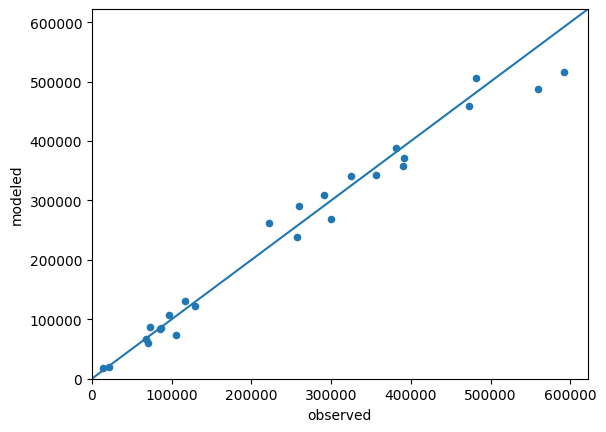

In [15]:
df = df.head(-1)
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2 : ' + str(r_value))

# External Stations

In [16]:
df = pd.read_csv(os.path.join(csv_path,'external_volumes.csv'))
df['percent_diff'] = df['diff']/df['observed']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df

C:\Users\modeller\AppData\Local\Temp\ipykernel_35540\2144700014.py:3: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,external_station,location,county,observed,modeled,diff,percent_diff
0,3733,I-5 to Olympia,Pierce,"129,250","129,248",-2,-0.0%
1,3744,I-5 to Mount Vernon,Snohomish,"65,880","65,830",-50,-0.1%
2,3739,I-90 @ Snoqualmie Pass,King,"30,500","30,463",-37,-0.1%
3,3746,SR-532 to Camano Island,Snohomish,"25,900","25,931",31,0.1%
4,3734,SR-507 to Yelm,Pierce,"22,700","22,703",3,0.0%
5,3749,SR-3 to Belfair,Kitsap,"20,329","20,206",-123,-0.6%
6,3748,Hood Canal Bridge,Kitsap,"18,200","18,129",-71,-0.4%
7,3745,Pioneer Way N/O Stanwood,Snohomish,"9,650","9,672",22,0.2%
8,3747,Mukilteo-Clinton Ferry,Snohomish,"6,290","6,370",80,1.3%
9,3750,SR-302 to Shelton,Pierce,"4,550","4,547",-3,-0.1%


r^2 : 0.99998854532758


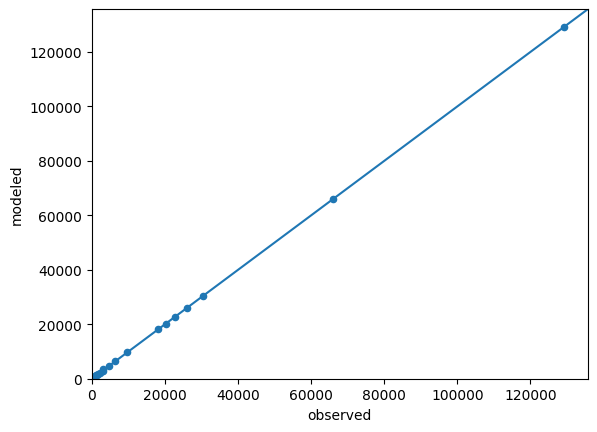

In [17]:
df = df.head(-1)
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2 : ' + str(r_value))

In [18]:
## External trips/VMT
try:
    df_23 = h5py.File(os.path.join(valid_config['model_dir'], 'inputs/model/daysim/roster/7to8.h5'))
    df_23_skims_sov = df_23['Skims']['sov_inc2d'][:]/100
    df_23_skims_hov2 = df_23['Skims']['hov2_inc2d'][:]/100
    df_23_skims_hov3 = df_23['Skims']['hov3_inc2d'][:]/100

    df_results_new = pd.DataFrame()

    tod_list = ['5to6', '6to7', '7to8', '8to9', '9to10', '10to14', '14to15', '15to16', '16to17', '17to18', '18to20', '20to5']
    for tod in tod_list:
    #     print(tod)
        df_temp = pd.DataFrame()
        for mode in ['sov','hov2','hov3']:
    #         print(mode)
            od_new = h5py.File(os.path.join(valid_config['model_dir'], 'outputs/supplemental/external_work_'+tod+'.h5'), 'r')[mode][:]
            df_temp.loc[tod,mode+'_vmt'] = (df_23_skims_sov*od_new).sum()
            df_temp.loc[tod,mode+'_trips'] = od_new.sum()
            df_temp.loc[tod,mode+'_avg_dist'] = df_temp.loc[tod,mode+'_vmt']/df_temp.loc[tod,mode+'_trips']
        df_results_new = pd.concat([df_results_new, df_temp ])
except:
    pass

In [19]:
try:
    df_vmt = pd.DataFrame(df_results_new[['sov_vmt','hov2_vmt','hov3_vmt']].sum(),
                columns=['VMT'])
    df_vmt.index = [i.split('_')[0].upper() for i in df_vmt.index]

    df_trips = pd.DataFrame(df_results_new[['sov_trips','hov2_trips','hov3_trips']].sum(),
                columns=['Trips'])
    df_trips.index = [i.split('_')[0].upper() for i in df_trips.index]

    df = df_vmt.merge(df_trips, left_index=True, right_index=True)

    df.loc['Total',:] = df.sum(axis=0)
    df['Avg Distance'] = df['VMT']/df['Trips']
    df
except:
    pass

# Trucks

In [20]:
daily_counts = pd.read_sql("SELECT * FROM daily_counts WHERE year="+str(input_config['base_year']), con=conn)

daily_counts['htrk_vehicles'] = daily_counts['htrk_vehicles'].astype('float').fillna(-1)

facility_type_lookup = {
    1: "Freeway",  # Interstate
    2: "Freeway",  # Ohter Freeway
    3: "Freeway",  # Expressway
    4: "Ramp",
    5: "Arterial",  # Principal arterial
    6: "Arterial",  # Minor Arterial
    7: "Collector",  # Major Collector
    8: "Collector",  # Minor Collector
    9: "Collector",  # Local
    10: "Busway",
    11: "Non-Motor",
    12: "Light Rail",
    13: "Commuter Rail",
    15: "Ferry",
    16: "Passenger Only Ferry",
    17: "Connector",  # centroid connector
    18: "Connector",  # facility connector
    19: "HOV",  # HOV Only Freeway
    20: "HOV",  # HOV Flag
}

In [21]:
# FIXME: move to validation.py

df_network = pd.read_csv(os.path.join(valid_config['model_dir'], 'outputs/network/network_results.csv'))
model_vol_df = df_network.copy()
model_vol_df["@facilitytype"] = model_vol_df["@facilitytype"].map(
    facility_type_lookup
)

# Get daily and model volumes
df_daily = (
    model_vol_df.groupby(["@countid"])
    .agg({"@tveh": "sum", "@facilitytype": "first", '@mveh': 'sum', '@hveh': 'sum'})
    .reset_index()
)

# Merge observed with model
df_daily = df_daily.merge(daily_counts, left_on="@countid", right_on="flag")

In [22]:
county_lookup = {
    33: 'King',
    35: 'Kitsap',
    53: 'Pierce',
    61: 'Snohomish'
}

df_daily['County'] = df_daily['countyid'].map(county_lookup)

In [23]:
df_daily_med = df_daily.copy()
df_daily_med.rename(columns={'@mveh': 'Model', 'mtrk_vehicles': 'Observed'}, inplace=True)
df_daily_med = df_daily_med[~df_daily_med['Observed'].isnull()]
for col in ['Model','Observed']:
    df_daily_med[col] = df_daily_med[col].astype('int')
df_daily_med = df_daily_med[df_daily_med['Observed'] > 0]

df_daily_heavy = df_daily.copy()
df_daily_heavy.rename(columns={'@hveh': 'Model', 'htrk_vehicles': 'Observed'}, inplace=True)
df_daily_heavy = df_daily_heavy[~df_daily_heavy['Observed'].isnull()]
for col in ['Model','Observed']:
    df_daily_heavy[col] = df_daily_heavy[col].astype('int')
df_daily_heavy = df_daily_heavy[df_daily_heavy['Observed'] > 0]

In [24]:
def create_truck_chart(df_daily, truck_type, county=None):

    if county:
        df_daily = df_daily[df_daily['County'] == county]
        title = truck_type + ' Trucks: '+county
    else:
        title = truck_type + ' Trucks: Region'

    slope, intercept, r_value, p_value, std_err = stats.linregress(df_daily['Observed'], df_daily['Model'])

    fig = px.scatter(df_daily, y='Model', x='Observed', title=title, hover_data=['location','County'])
    fig.update_layout(height=600, width=800, margin=dict(l=100, r=100, t=100, b=100))

    # Get max value, either observed or modeled
    max_val = df_daily[['Observed','Model']].max().max()

    # Add 45-degree line
    fig.add_shape(
        type="line",
        x0=0, y0=0,
        x1=max_val, y1=max_val,
        line=dict(color="Red", width=2, dash="dash")
    )

    # Add best fit line
    x_fit = np.linspace(0, max(df_daily['Observed']), 100)
    y_fit = slope * x_fit + intercept
    fig.add_trace(px.line(x=x_fit, y=y_fit, labels={'x':'Observed', 'y':'Model'}).data[0])
    fig.update_traces(line=dict(color="Grey", width=2))

    # Add label for 45-degree line

    fig.add_annotation(
        x=max_val*1.05,
        y=max_val*1.05,
        text='y = x',
        showarrow=False,
        font=dict(size=12, color="pink"),
        align="right"
    )

    # Add R-squared value as annotation
    fig.add_annotation(
        x=max(x_fit)*1.05,
        y=max(y_fit)*1.05,
        text=f'r^2 = {r_value**2:.2f}',
        showarrow=False,
        font=dict(size=12, color="black"),
        align="right"
    )

    return fig


### Heavy Truck Counts

In [25]:
fig = create_truck_chart(df_daily_heavy, 'Heavy')
fig.show()

In [26]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'King')
fig.show()

In [27]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'Kitsap')
fig.show()

In [28]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'Pierce')
fig.show()

In [29]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'Snohomish')
fig.show()

### Medium Truck Counts

In [30]:
fig = create_truck_chart(df_daily_med, 'Medium')
fig.show()

In [31]:
fig = create_truck_chart(df_daily_med, 'Medium', 'King')
fig.show()

In [32]:
fig = create_truck_chart(df_daily_med, 'Medium', 'Kitsap')
fig.show()

In [33]:
fig = create_truck_chart(df_daily_med, 'Medium', 'Pierce')
fig.show()

In [34]:
fig = create_truck_chart(df_daily_med, 'Medium', 'Snohomish')
fig.show()